### 验证投影近似是否正确



In [26]:
import numpy as np
import matplotlib.pyplot as plt

data_bg = np.load('SE_bg.npz', allow_pickle=True) # 读取npz文件，返回一个字典
data_s1 = np.load('sphere_disSG2_20.npz', allow_pickle=True) 
data_s2 = np.load('sphere_disSG2_40.npz', allow_pickle=True)
data_s3 = np.load('sphere_disSG2_100.npz', allow_pickle=True)
# data_s4 = np.load('sphere_disSG2_20.npz', allow_pickle=True)
# data_s5 = np.load('sphere_disSG2_10.npz', allow_pickle=True)

print('npz文件保存的文件包括: ', data_bg.files) # 打印全部文件名
print('npz文件保存的文件包括: ', data_s1.files) # 打印全部文件名

npz文件保存的文件包括:  ['visTotal', 'ampTotal']
npz文件保存的文件包括:  ['visTotal', 'ampTotal']


In [27]:
Vis_bg = data_bg['visTotal']
Vis_s1 = data_s1['visTotal']
Vis_s2 = data_s2['visTotal']
Vis_s3 = data_s3['visTotal']
# Vis_s4 = data_s4['visTotal']
# Vis_s5 = data_s5['visTotal']

xi = np.load('xi.npy')
# np.save('xi.npy', xi)
print(xi)


[3.44400556e-07 6.88801111e-07 1.03320167e-06 1.37760222e-06
 1.72200278e-06 2.06640333e-06 2.41080389e-06 2.75520444e-06
 3.09960500e-06 3.44400556e-06 3.78840611e-06 4.13280667e-06
 4.47720722e-06 4.82160778e-06 5.16600833e-06]


In [28]:
data_bg.close() # 关闭文件
data_s1.close() # 关闭文件
data_s2.close() # 关闭文件
# data_s3.close() # 关闭文件
# data_s4.close() # 关闭文件
# data_s5.close() # 关闭文件

In [29]:
pad_width = 1  

df = np.zeros((5, xi.shape[0]))
df_err = np.zeros((5, xi.shape[0]))
trans = np.zeros((5, xi.shape[0]))
trans_err = np.zeros((5, xi.shape[0]))

for i in range(xi.shape[0]):
    new_shape = (Vis_s1[0][i].shape[0] - 2 * pad_width, Vis_s1[0][i].shape[1] - 2 * pad_width)
    if i == 0:
        Vis_bg[0][0] = Vis_bg[0][0][pad_width:new_shape[0] + pad_width, pad_width:new_shape[1] + pad_width]

    Vis_s1[0][i] = Vis_s1[0][i][pad_width:new_shape[0] + pad_width, pad_width:new_shape[1] + pad_width]
    Vis_s2[0][i] = Vis_s2[0][i][pad_width:new_shape[0] + pad_width, pad_width:new_shape[1] + pad_width]
    Vis_s3[0][i] = Vis_s3[0][i][pad_width:new_shape[0] + pad_width, pad_width:new_shape[1] + pad_width]
    # Vis_s4[0][i] = Vis_s4[0][i][pad_width:new_shape[0] + pad_width, pad_width:new_shape[1] + pad_width]
    # Vis_s5[0][i] = Vis_s5[0][i][pad_width:new_shape[0] + pad_width, pad_width:new_shape[1] + pad_width]
    

    
    df[0,i] = np.mean(Vis_s1[0][i]/Vis_bg[0][0])
    df_err[0,i] = np.std(Vis_s1[0][i]/Vis_bg[0][0])
    df[1,i] = np.mean(Vis_s2[0][i]/Vis_bg[0][0])
    df_err[1,i] = np.std(Vis_s2[0][i]/Vis_bg[0][0])
    df[2,i] = np.mean(Vis_s3[0][i]/Vis_bg[0][0])
    df_err[2,i] = np.std(Vis_s3[0][i]/Vis_bg[0][0])
    # df[3,i] = np.mean(Vis_s4[0][i]/Vis_bg[0][0])
    # df_err[3,i] = np.std(Vis_s4[0][i]/Vis_bg[0][0])
    # df[4,i] = np.mean(Vis_s5[0][i]/Vis_bg[0][0])
    # df_err[4,i] = np.std(Vis_s5[0][i]/Vis_bg[0][0])



In [30]:
## 体积分数0.4的小球理论暗场计算
import numpy as np
import scipy.io
import scipy.interpolate
import matplotlib.pyplot as plt

# 加载 .mat 文件
mat_file = 'varyVF_40um.mat'  # 替换为你的 .mat 文件路径
data = scipy.io.loadmat(mat_file)

G_norm_total = data['G_norm_total'][4,:].flatten()
G0_total = data['G0_total'][4,:].flatten()
xi_list = data['xi_list'].flatten()

interp_func = scipy.interpolate.interp1d(xi_list, G_norm_total, kind='cubic')  # 使用三次样条插值

G_norm = interp_func(xi)

DF_theory = np.exp(2.4e-4 * G0_total * (G_norm - 1))
print()
print(DF_theory[8])




0.8278640392918163


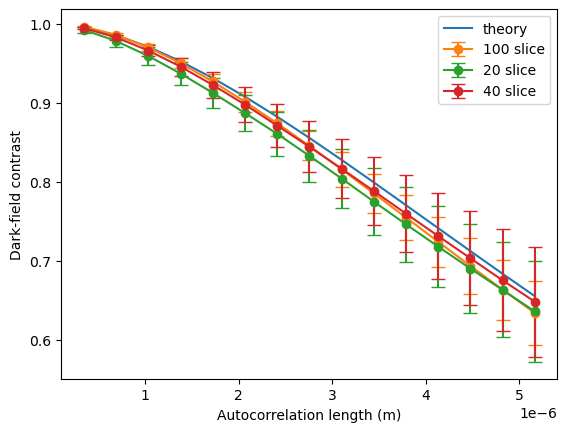

In [32]:
xi = np.squeeze(xi)

# compare the simulation and theory
plt.figure()
plt.plot(xi, DF_theory, label='theory')
# plt.errorbar(xi, df[0].squeeze(), yerr=df_err[0].squeeze(), capsize=5, fmt='-o', label='1 slice')
# plt.errorbar(xi, df[4].squeeze(), yerr=df_err[4].squeeze(), capsize=5, fmt='-o', label='10 slice')
plt.errorbar(xi, df[2].squeeze(), yerr=df_err[2].squeeze(), capsize=5, fmt='-o', label='100 slice')
plt.errorbar(xi, df[0].squeeze(), yerr=df_err[0].squeeze(), capsize=5, fmt='-o', label='20 slice')
plt.errorbar(xi, df[1].squeeze(), yerr=df_err[1].squeeze(), capsize=5, fmt='-o', label='40 slice')

# plt.ylim([0.8,1])
plt.legend(loc='upper right')
plt.xlabel('Autocorrelation length (m)')
plt.ylabel('Dark-field contrast')
plt.show()